In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.metrics import r2_score

In [2]:
data=pd.read_csv("kc_house_data.csv")
data.isnull().sum()
data.drop(['sqft_above','view'],axis='columns', inplace=True)


In [3]:
data.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,condition,grade,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,3,7,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,3,7,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,3,6,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,5,7,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,3,8,0,1987,0,98074,47.6168,-122.045,1800,7503


In [4]:
data.tail()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,condition,grade,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,3,8,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,3,8,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,3,7,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,3,8,0,2004,0,98027,47.5345,-122.069,1410,1287
21612,1523300157,20141015T000000,325000.0,2,0.75,1020,1076,2.0,0,3,7,0,2008,0,98144,47.5941,-122.299,1020,1357


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   condition      21613 non-null  int64  
 10  grade          21613 non-null  int64  
 11  sqft_basement  21613 non-null  int64  
 12  yr_built       21613 non-null  int64  
 13  yr_renovated   21613 non-null  int64  
 14  zipcode        21613 non-null  int64  
 15  lat            21613 non-null  float64
 16  long           21613 non-null  float64
 17  sqft_living15  21613 non-null  int64  
 18  sqft_l

In [6]:
y=data[['price']].values#dependent variable
x=data.drop(['id','price','date'],axis=1).values# x carries all independent variables like noof bedrooms,bathroroms,floors etc 

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)

In [24]:
#model training
lire=LinearRegression()
lire.fit(x_train,y_train)

LinearRegression()

In [25]:
y_predict=lire.predict(x_test)
print(y_predict)
print(y_test)

[[379671.37462533]
 [228357.74954364]
 [371644.82571748]
 ...
 [872989.89744961]
 [606177.76273102]
 [598439.79327231]]
[[425000.]
 [399000.]
 [202000.]
 ...
 [650000.]
 [630000.]
 [555000.]]


In [31]:
input_data=(3,1.00,1180	,5650,	1.0	,0,	3,7,0,1955,0,98178,47.5112,-122.257,1340,565)
input_data_np=np.asarray(input_data)
input_data_reshape=input_data_np.reshape(1,-1)  
prediction= lire.predict(input_data_reshape)
print("price=",prediction[0,0])

price= 219372.47355296137


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
data=[]
features=['bedrooms','bathrooms','sqft_living','sqft_lot','floors','waterfront','view','condition','grade','sqft_above','sqft_basement','yr_built','yr_renovated','zipcode','lat,long','sqft_living15','sqft_lot15']
for i in range(16):
    print(features[i],end=" ")
    k=float(input("enter value :"))
    data.append(k)
input_data_np=np.asarray(data)
input_data_reshape=input_data_np.reshape(1,-1)   
prediction= lire.predict(input_data_reshape)
print(prediction)

bedrooms 

In [28]:
 print('coefficient of determinant: %.3f' % r2_score(y_test,y_predict)) #here we are checking values of testing and machine predicting values

coefficient of determinant: 0.699


Text(0.5, 1.0, 'accuracy')

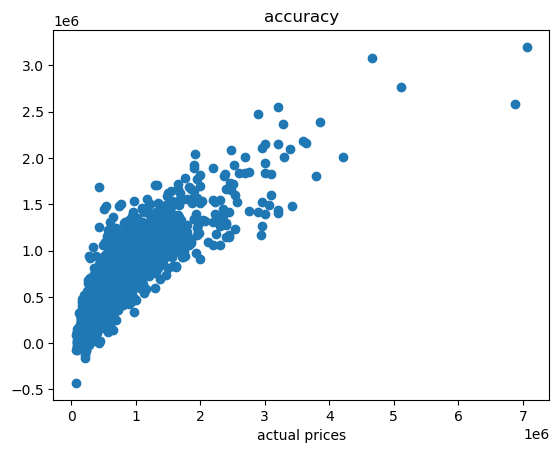

In [11]:
import matplotlib
import matplotlib.pyplot as plt
plt.scatter(y_test,y_predict)
plt.xlabel("actual prices",)
plt.title("accuracy")